### RaschPy bistretch MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `bistretch` parameterisation combines both stretch axes at once: it restricts the fully-free `bivector` parameterisation (a separate severity per rater x item component plus a separate severity per rater x threshold component) down to just three parameters per rater: a severity shift `lambda_r`, an item-difficulty-stretch `omega_items_r`, and a threshold-stretch `omega_thresholds_r`. It's the natural parsimonious middle ground when a rater shows genuine structure on *both* axes simultaneously – rather than only one, which the `pseudo_halo` and `centrality` parameterisations already cover individually. `omega_items_r`/`omega_thresholds_r` are interpreted exactly as in `pseudo_halo`/`centrality` respectively; `omega_items_r == omega_thresholds_r == 1` is neutral and collapses to the `global` model. Because it's recovered closed-form from an already-calibrated `bivector` fit, it sits strictly between `global` (1 free parameter per rater) and `bivector` (`(I-1)+(K-1)` free parameters per rater) and can be compared against both directly via `model_selection()`.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected – if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Bistretch(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96188/4286612355.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_Bistretch` simulator, which generates data with *true* `lambda_r`/`omega_items_r`/`omega_thresholds_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_Bistretch(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5,
                            category_base=1.5, global_range=1.5, stretch_range=0.6, missing=0, seed=999)
sim.responses.to_csv('mfrm_bistretch_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_bistretch_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     1.0     4.0     3.0     2.0     3.0     2.0     4.0   
        Person_2     0.0     1.0     2.0     1.0     2.0     3.0     2.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     3.0      4.0      4.0      2.0  
        Person_2     2.0     3.0      3.0      3.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the bistretch parameterisation. This first runs the full `bivector` PAIR estimation internally (a separate severity per rater x item component and per rater x threshold component), then closed-form derives each rater's `lambda_r`/`omega_items_r` from the item component and `omega_thresholds_r` from the threshold component – no new estimation. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_bistretch()

CPU times: user 34.2 ms, sys: 8.01 ms, total: 42.2 ms
Wall time: 47.5 ms


`lambda_r/omega_items_r/omega_thresholds_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_bistretch(regression='theil-sen')

Check the item location estimates - view the first two items

In [11]:
mfrm.items.head(2)

Item_1    1.024723
Item_2    0.279334
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [12]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                               {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

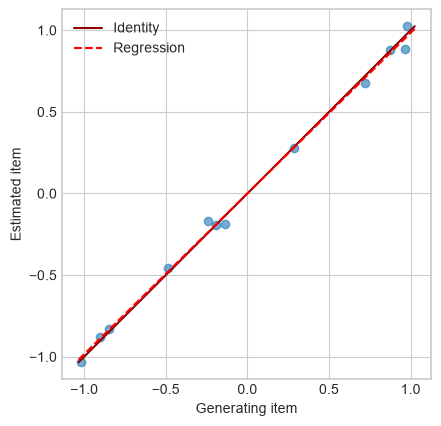

item Pearson correlation:              0.998
item SD ratio (estimated / generating): 0.986
item Regression coefficient:            0.984
item RMSE:                               0.04


In [13]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_bistretch_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [14]:
%%time
mfrm.item_stats_df_bistretch(full=True)
mfrm.item_stats_bistretch.to_csv('mfrm_bistretch_item_stats.csv')

CPU times: user 16.9 s, sys: 139 ms, total: 17.1 s
Wall time: 17.1 s


Check the item statistics table

In [15]:
mfrm.item_stats_bistretch

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,1.025,0.040,0.948,1.103,1600,0.392,0.956,-1.256,0.956,-1.253,0.654,0.654
Item_2,0.279,0.040,0.201,0.353,1600,0.481,0.984,-0.444,0.968,-0.907,0.686,0.673
Item_3,-0.455,0.039,-0.533,-0.377,1600,0.571,0.992,-0.215,1.006,0.184,0.690,0.677
Item_4,0.678,0.038,0.601,0.753,1600,0.428,0.929,-2.038,0.934,-1.890,0.665,0.665
Item_5,0.888,0.041,0.808,0.968,1600,0.402,1.010,0.301,1.003,0.097,0.653,0.659
Item_6,-0.187,0.038,-0.258,-0.113,1600,0.535,0.928,-2.074,0.933,-1.916,0.717,0.677
Item_7,-0.194,0.038,-0.273,-0.123,1600,0.535,0.954,-1.306,0.978,-0.624,0.689,0.677
Item_8,-1.034,0.041,-1.106,-0.945,1600,0.638,0.969,-0.884,0.961,-1.105,0.694,0.673
Item_9,-0.833,0.043,-0.915,-0.751,1600,0.613,1.007,0.214,1.005,0.167,0.656,0.675
Item_10,-0.166,0.032,-0.228,-0.104,1600,0.539,1.007,0.206,1.018,0.526,0.653,0.677


Generate a table of threshold statistics (and check run time), and save to file

In [16]:
%%time
mfrm.threshold_stats_df_bistretch(full=True)
mfrm.threshold_stats_bistretch.to_csv('mfrm_bistretch_threshold_stats.csv')

CPU times: user 68.4 ms, sys: 964 μs, total: 69.4 ms
Wall time: 69.2 ms


Check the threshold statistics table

In [17]:
mfrm.threshold_stats_bistretch

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-3.034,0.052,-3.111,-2.913,0.953,-2.641,0.920,-2.485,1.083,0.440,0.436
Threshold 2,-1.171,0.035,-1.233,-1.097,0.983,-1.581,0.978,-1.381,1.049,0.571,0.548
Threshold 3,-0.969,0.031,-1.023,-0.902,1.004,0.370,0.997,-0.161,0.997,0.690,0.683
Threshold 4,1.783,0.030,1.719,1.832,0.999,-0.102,0.983,-0.849,1.005,0.704,0.707
Threshold 5,3.391,0.056,3.261,3.478,0.996,-0.162,1.037,0.762,1.000,0.332,0.317


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

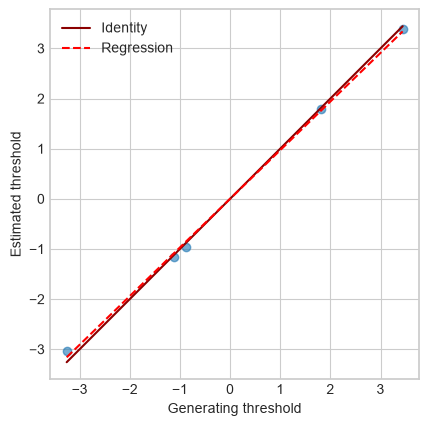

threshold Pearson correlation:              0.999
threshold SD ratio (estimated / generating): 0.971
threshold Regression coefficient:            0.97
threshold RMSE:                               0.115


In [18]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_bistretch_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [19]:
%%time
mfrm.rater_stats_df_bistretch()
mfrm.rater_stats_bistretch.to_csv('mfrm_bistretch_rater_stats.csv')
mfrm.rater_stats_bistretch_full_vector.to_csv('mfrm_bistretch_rater_stats_full_vector.csv')

CPU times: user 38.6 ms, sys: 701 μs, total: 39.3 ms
Wall time: 39.3 ms


Check the rater statistics table

In [20]:
mfrm.rater_stats_bistretch

lambda        omega_items        omega_thresholds         \
        Estimate     SE    Estimate     SE         Estimate     SE   
Rater_1    0.450  0.048       1.274  0.065            0.730  0.025   
Rater_2   -0.646  0.067       0.624  0.089            0.890  0.038   
Rater_3    0.295  0.049       1.076  0.066            0.987  0.026   
Rater_4    0.269  0.055       1.070  0.080            1.252  0.032   
Rater_5   -0.612  0.069       1.122  0.091            1.154  0.042   
Rater_6    0.651  0.051       1.014  0.087            0.827  0.031   
Rater_7   -0.696  0.069       0.930  0.107            1.062  0.041   
Rater_8    0.287  0.052       0.877  0.063            1.104  0.035   

        Overall statistics                     
                     Count Infit MS Outfit MS  
Rater_1             2400.0    0.975     0.961  
Rater_2             2400.0    0.962     0.965  
Rater_3             2400.0    0.975     0.981  
Rater_4             2400.0    1.024     1.037  
Rater_5             2400.0    1.000     1.001  
Rater_6             2400.0    0.943     0.951  
Rater_7             2400.0    0.915     0.905  
Rater_8             2400.0    1.003     1.013

`self.rater_stats_bistretch` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega_items`, `omega_thresholds`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately.

In [21]:
mfrm.rater_stats_bistretch_full_vector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.730  0.084    0.526  0.052    0.325  0.057    0.635  0.067   
Rater_2   -1.032  0.090   -0.751  0.063   -0.475  0.093   -0.902  0.072   
Rater_3    0.372  0.069    0.316  0.047    0.260  0.066    0.346  0.054   
Rater_4    0.341  0.089    0.289  0.055    0.238  0.072    0.317  0.068   
Rater_5   -0.488  0.107   -0.578  0.070   -0.668  0.086   -0.530  0.086   
Rater_6    0.666  0.106    0.655  0.058    0.645  0.061    0.661  0.081   
Rater_7   -0.768  0.134   -0.716  0.078   -0.665  0.080   -0.744  0.104   
Rater_8    0.161  0.071    0.253  0.051    0.344  0.066    0.204  0.057   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    0.692  0.076  ...       0.040       0.278  0.036      -0.466   
Rater_2   -0.980  0.081  ...       0.046       0.106  0.039      -0.195   
Rater_3    0.362  0.063  ...       0.034       0.012  0.029      -0.023   
Rater_4    0.331  0.081  ...       0.039      -0.245  0.032       0.450   
Rater_5   -0.504  0.099  ...       0.066      -0.174  0.058       0.251   
Rater_6    0.664  0.096  ...       0.039       0.168  0.033      -0.309   
Rater_7   -0.758  0.123  ...       0.052      -0.060  0.045       0.110   
Rater_8    0.178  0.066  ...       0.032      -0.089  0.026       0.196   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.043      -0.900  0.077             2400.0    0.975     0.961  
Rater_2  0.071      -0.372  0.130             2400.0    0.962     0.965  
Rater_3  0.048      -0.043  0.088             2400.0    0.975     0.981  
Rater_4  0.057       0.856  0.104             2400.0    1.024     1.037  
Rater_5  0.071       0.499  0.137             2400.0    1.000     1.001  
Rater_6  0.063      -0.588  0.112             2400.0    0.943     0.951  
Rater_7  0.076       0.210  0.139             2400.0    0.915     0.905  
Rater_8  0.082       0.363  0.138             2400.0    1.003     1.013  

[8 rows x 37 columns]

The three parameters `lambda_bistretch` (severity shift), `omega_items_bistretch` (item-difficulty stretch) and `omega_thresholds_bistretch` (threshold stretch) are the actual summary the model produces – `mfrm.raters_bistretch` above is just their reconstruction back into full (rater x item) x threshold form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `bivector` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for both stretch parameters, following Jin & Wang (2018)'s own notation for a rater stretch factor – each is a multiplicative parameter rather than an additive one, so together they deserve a distinct Greek letter from the shift. A rater near `omega_items=1`/`omega_thresholds=1` is showing undistorted perceptions on that axis; departures above or below 1 carry the same interpretation as the corresponding single-axis `pseudo_halo`/`centrality` parameter.

In [22]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_bistretch, 'omega_items (item stretch)': mfrm.omega_items_bistretch, 'omega_thresholds (threshold stretch)': mfrm.omega_thresholds_bistretch}).round(3)

,lambda (severity),omega_items (item stretch),omega_thresholds (threshold stretch)
Rater_1,0.450,1.274,0.730
Rater_2,-0.646,0.624,0.890
Rater_3,0.295,1.076,0.987
Rater_4,0.269,1.070,1.252
Rater_5,-0.612,1.122,1.154
Rater_6,0.651,1.014,0.827
Rater_7,-0.696,0.930,1.062
Rater_8,0.287,0.877,1.104


Pass `alias=True` to `rater_stats_df_bistretch()` to relabel these columns with a human-readable name instead of the raw parameter names: `'Global'` for `lambda`, `'Item stretch'` for `omega_items`, `'Threshold stretch'` for `omega_thresholds` – purely cosmetic, values remain unchanged:

In [23]:
mfrm.rater_stats_df_bistretch(alias=True)
mfrm.rater_stats_bistretch

Global        Item stretch        Threshold stretch         \
        Estimate     SE     Estimate     SE          Estimate     SE   
Rater_1    0.450  0.048        1.274  0.065             0.730  0.025   
Rater_2   -0.646  0.067        0.624  0.089             0.890  0.038   
Rater_3    0.295  0.049        1.076  0.066             0.987  0.026   
Rater_4    0.269  0.055        1.070  0.080             1.252  0.032   
Rater_5   -0.612  0.069        1.122  0.091             1.154  0.042   
Rater_6    0.651  0.051        1.014  0.087             0.827  0.031   
Rater_7   -0.696  0.069        0.930  0.107             1.062  0.041   
Rater_8    0.287  0.052        0.877  0.063             1.104  0.035   

        Overall statistics                     
                     Count Infit MS Outfit MS  
Rater_1             2400.0    0.975     0.961  
Rater_2             2400.0    0.962     0.965  
Rater_3             2400.0    0.975     0.981  
Rater_4             2400.0    1.024     1.037  
Rater_5             2400.0    1.000     1.001  
Rater_6             2400.0    0.943     0.951  
Rater_7             2400.0    0.915     0.905  
Rater_8             2400.0    1.003     1.013

Since `bistretch` restricts both axes at once, the divergence test runs twice – once against `bivector`'s own item marginal, once against its threshold marginal – giving separate `'Flagged items'` and `'Flagged categories'` columns:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` only matters if `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. If you're not economising on `no_of_samples`, there's no reason to prefer `'t'` over `'wald'`; just use `'wald'` (optionally with a larger `no_of_samples`, which improves the underlying SE estimate itself rather than just widening the reference distribution around it).

Passing `full=True` adds one plain True/False column per item and threshold to the primary table itself, directly after the `'Flagged items'/'Flagged categories'` count, for scanning flagged status across all elements at a glance – and `rater_stats_bistretch_full_vector` receives a per-element `'Flagged'` column added to each threshold's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_bistretch` is displayed here transposed using `.T` for visual convenience.

In [24]:
mfrm.rater_stats_df_bistretch(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_bistretch.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate     0.45  -0.646   0.295   0.269  -0.612   0.651   
                   SE          0.048   0.062   0.048   0.055   0.071   0.056   
                   2.5%        0.389   -0.81   0.213   0.183  -0.773   0.603   
                   97.5%       0.571  -0.555   0.398   0.401  -0.509   0.831   
omega_items        Estimate    1.274   0.624   1.076    1.07   1.122   1.014   
                   SE          0.068   0.083   0.066   0.083   0.088   0.087   
                   2.5%         1.19   0.473   0.949   0.856   0.939   0.853   
                   97.5%        1.46   0.808   1.198    1.19   1.273   1.204   
omega_thresholds   Estimate     0.73    0.89   0.987   1.252   1.154   0.827   
                   SE          0.025   0.034   0.025   0.032   0.043   0.029   
                   2.5%        0.675   0.832   0.937   1.194   1.071   0.758   
                   97.5%       0.771   0.966   1.029   1.317   1.238   0.873   
Flagged items      Count         0.0     0.0     0.0     0.0     0.0     1.0   
Flagged categories Count         0.0     0.0     0.0     3.0     0.0     0.0   
Item_1             Flagged     False   False   False   False   False   False   
Item_2             Flagged     False   False   False   False   False   False   
Item_3             Flagged     False   False   False   False   False   False   
Item_4             Flagged     False   False   False   False   False    True   
Item_5             Flagged     False   False   False   False   False   False   
Item_6             Flagged     False   False   False   False   False   False   
Item_7             Flagged     False   False   False   False   False   False   
Item_8             Flagged     False   False   False   False   False   False   
Item_9             Flagged     False   False   False   False   False   False   
Item_10            Flagged     False   False   False   False   False   False   
Item_11            Flagged     False   False   False   False   False   False   
Item_12            Flagged     False   False   False   False   False   False   
Threshold 1        Flagged     False   False   False    True   False   False   
Threshold 2        Flagged     False   False   False   False   False   False   
Threshold 3        Flagged     False   False   False    True   False   False   
Threshold 4        Flagged     False   False   False   False   False   False   
Threshold 5        Flagged     False   False   False    True   False   False   
Overall statistics Count      2400.0  2400.0  2400.0  2400.0  2400.0  2400.0   
                   Infit MS    0.975   0.962   0.975   1.024     1.0   0.943   
                   Infit Z    -0.866  -1.305  -0.865   0.813   0.024  -2.011   
                   Outfit MS   0.961   0.965   0.981   1.037   1.001   0.951   
                   Outfit Z   -1.252  -1.198  -0.637   1.152   0.052  -1.635   

                             Rater_7 Rater_8  
lambda             Estimate   -0.696   0.287  
                   SE           0.07   0.054  
                   2.5%       -0.884   0.186  
                   97.5%      -0.626   0.389  
omega_items        Estimate     0.93   0.877  
                   SE          0.101   0.067  
                   2.5%        0.771   0.729  
                   97.5%       1.165   0.999  
omega_thresholds   Estimate    1.062   1.104  
                   SE          0.037   0.033  
                   2.5%        1.004   1.045  
                   97.5%       1.153   1.168  
Flagged items      Count         0.0     0.0  
Flagged categories Count         0.0     0.0  
Item_1             Flagged     False   False  
Item_2             Flagged     False   False  
Item_3             Flagged     False   False  
Item_4             Flagged     False   False  
Item_5             Flagged     False   False  
Item_6             Flagged     False   False  
Item_7             Flagged     False   False  
Item_8             Flagged     Fal

Recovery check on the model's `mfrm.generating.lambda_`, `mfrm.generating.omega_items` and `mfrm.generating.omega_thresholds` parameters. Plotted separately since they are on different scales:

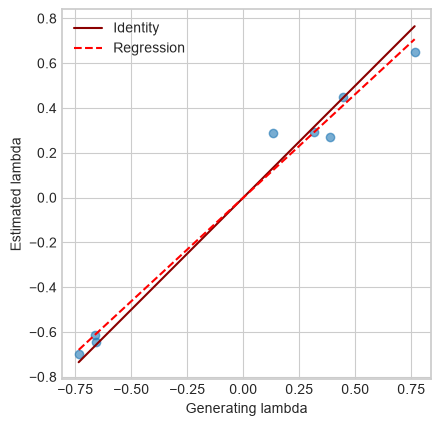

lambda Pearson correlation:              0.99
lambda SD ratio (estimated / generating): 0.934
lambda Regression coefficient:            0.925
lambda RMSE:                               0.083


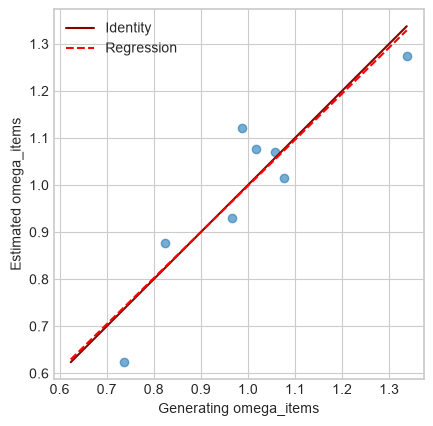

omega_items Pearson correlation:              0.907
omega_items SD ratio (estimated / generating): 1.08
omega_items Regression coefficient:            0.98
omega_items RMSE:                               0.076


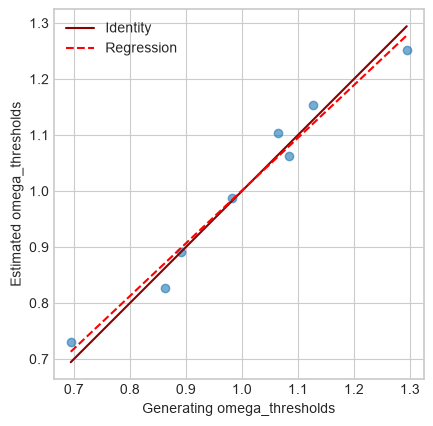

omega_thresholds Pearson correlation:              0.985
omega_thresholds SD ratio (estimated / generating): 0.956
omega_thresholds Regression coefficient:            0.941
omega_thresholds RMSE:                               0.03


In [25]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_bistretch, 'lambda', 'my_mfrm_bistretch_lambda_recovery.png')
recovery_plot(mfrm.generating.omega_items, mfrm.omega_items_bistretch, 'omega_items', 'my_mfrm_bistretch_omega_items_recovery.png')
recovery_plot(mfrm.generating.omega_thresholds, mfrm.omega_thresholds_bistretch, 'omega_thresholds', 'my_mfrm_bistretch_omega_thresholds_recovery.png')

And the correlations between true and estimated values for each parameter:

In [26]:
for param, sim_attr in [('lambda', 'lambda_'), ('omega_items', 'omega_items'), ('omega_thresholds', 'omega_thresholds')]:
    true_vals = getattr(sim, sim_attr)
    est_vals = getattr(mfrm, f'{param}_bistretch')
    r = np.corrcoef(true_vals, est_vals.reindex(true_vals.index))[0, 1]
    print(f'{param}: r = {r:.3f}')

lambda: r = 0.990
omega_items: r = 0.907
omega_thresholds: r = 0.985


Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_bistretch(full=True)
mfrm.person_stats_bistretch.to_csv('mfrm_bistretch_person_stats.csv')

CPU times: user 14.4 ms, sys: 810 μs, total: 15.2 ms
Wall time: 15.1 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_bistretch.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,1.138,0.142,0.139,314,480,0.654,0.970,0.969,-0.146,-0.152
Person_2,-0.868,0.123,0.115,198,480,0.412,0.882,0.921,-0.849,-0.517
Person_3,-3.022,0.153,0.159,70,480,0.146,1.077,0.971,0.517,-0.107
Person_4,-0.010,0.130,0.128,252,480,0.525,0.968,0.931,-0.165,-0.397
Person_5,0.652,0.137,0.132,289,480,0.602,0.925,0.869,-0.438,-0.804
Person_6,-0.777,0.123,0.123,204,480,0.425,0.992,1.014,-0.008,0.147
Person_7,-0.243,0.128,0.124,238,480,0.496,0.935,0.930,-0.398,-0.411
Person_8,-0.973,0.122,0.110,191,480,0.398,0.801,0.857,-1.523,-1.002
Person_9,0.901,0.140,0.147,302,480,0.629,1.104,1.129,0.697,0.834
Person_10,-2.010,0.128,0.138,123,480,0.256,1.160,1.095,1.145,0.681


And the same recovery check for person locations, against `mfrm.generating.persons`:

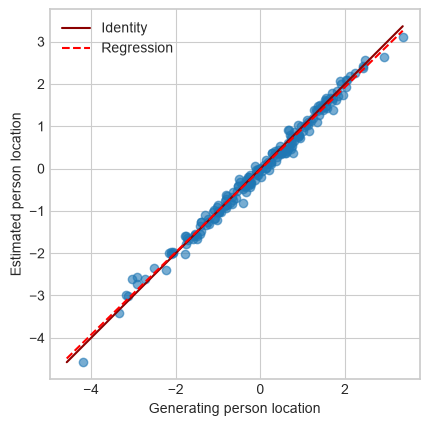

person location Pearson correlation:              0.995
person location SD ratio (estimated / generating): 0.98
person location Regression coefficient:            0.975
person location RMSE:                               0.136


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_bistretch, 'person location', 'my_mfrm_bistretch_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_bistretch()
mfrm.test_stats_bistretch.to_csv('mfrm_bistretch_test_stats.csv')

CPU times: user 2.76 ms, sys: 401 μs, total: 3.16 ms
Wall time: 3.14 ms


Check the test statistics table

In [31]:
mfrm.test_stats_bistretch

,Items,Persons
Mean,-0.000,-0.024
SD,0.738,1.305
Separation ratio,18.335,9.751
Strata,24.780,13.334
Reliability,0.997,0.990


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [32]:
%%time
mfrm.item_res_corr_analysis_bistretch()
mfrm.item_residual_correlations_bistretch.to_csv('mfrm_bistretch_item_residual_correlations.csv')
mfrm.item_loadings_bistretch.to_csv('mfrm_bistretch_item_loadings.csv')

CPU times: user 6.53 ms, sys: 2.17 ms, total: 8.7 ms
Wall time: 12.5 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_bistretch, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.016,-0.039,0.025,-0.010,0.037,-0.030,-0.010,0.035,-0.015,-0.013,-0.029
Item_2,-0.016,1.000,-0.070,-0.020,0.016,-0.028,0.010,-0.011,-0.019,-0.024,0.029,-0.010
Item_3,-0.039,-0.070,1.000,0.013,-0.017,-0.003,-0.014,-0.049,-0.014,0.001,-0.021,-0.052
Item_4,0.025,-0.020,0.013,1.000,-0.024,-0.043,-0.018,0.012,0.007,-0.016,-0.009,0.019
Item_5,-0.010,0.016,-0.017,-0.024,1.000,-0.012,-0.023,-0.005,-0.004,-0.010,-0.033,0.026
Item_6,0.037,-0.028,-0.003,-0.043,-0.012,1.000,0.007,-0.051,0.025,0.004,-0.057,-0.077
Item_7,-0.030,0.010,-0.014,-0.018,-0.023,0.007,1.000,0.007,-0.003,-0.007,-0.023,0.000
Item_8,-0.010,-0.011,-0.049,0.012,-0.005,-0.051,0.007,1.000,0.018,-0.014,0.004,-0.049
Item_9,0.035,-0.019,-0.014,0.007,-0.004,0.025,-0.003,0.018,1.000,0.011,-0.011,0.006
Item_10,-0.015,-0.024,0.001,-0.016,-0.010,0.004,-0.007,-0.014,0.011,1.000,-0.032,-0.030


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_bistretch['PC 1'], 3)

Item_1     0.072
Item_2    -0.135
Item_3     0.122
Item_4    -0.032
Item_5    -0.053
Item_6     0.193
Item_7    -0.012
Item_8    -0.069
Item_9     0.054
Item_10    0.084
Item_11   -0.094
Item_12   -0.126
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_bistretch()
mfrm.rater_residual_correlations_bistretch.to_csv('mfrm_bistretch_rater_residual_correlations.csv')
mfrm.rater_loadings_bistretch.to_csv('mfrm_bistretch_rater_loadings.csv')

CPU times: user 9.58 ms, sys: 886 μs, total: 10.5 ms
Wall time: 10.3 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_bistretch, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.007,-0.026,-0.027,-0.020,0.023,-0.015,0.004
Rater_2,-0.007,1.000,-0.009,-0.006,-0.018,-0.012,-0.027,0.002
Rater_3,-0.026,-0.009,1.000,-0.006,-0.003,-0.013,0.009,-0.025
Rater_4,-0.027,-0.006,-0.006,1.000,-0.030,-0.017,-0.014,-0.005
Rater_5,-0.020,-0.018,-0.003,-0.030,1.000,-0.043,-0.018,-0.028
Rater_6,0.023,-0.012,-0.013,-0.017,-0.043,1.000,-0.030,-0.045
Rater_7,-0.015,-0.027,0.009,-0.014,-0.018,-0.030,1.000,-0.047
Rater_8,0.004,0.002,-0.025,-0.005,-0.028,-0.045,-0.047,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_bistretch['PC 1'], 3)

Rater_1    0.128
Rater_2    0.111
Rater_3   -0.184
Rater_4    0.027
Rater_5   -0.116
Rater_6    0.027
Rater_7   -0.206
Rater_8    0.221
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

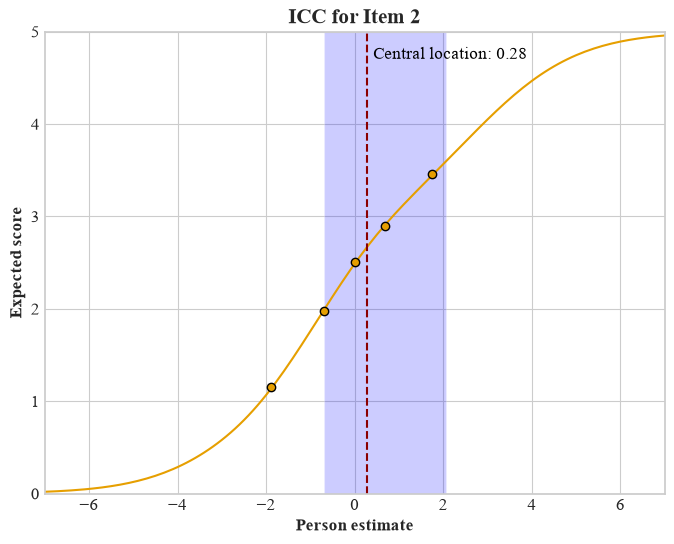

In [38]:
mfrm.icc_bistretch('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_bistretch_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

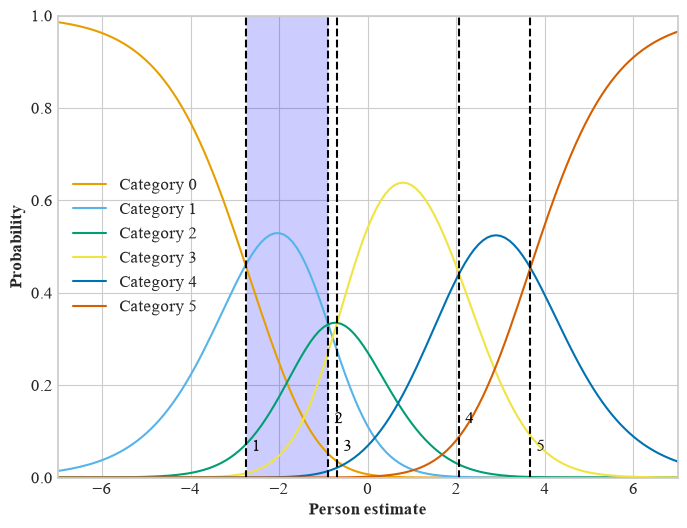

In [39]:
mfrm.crcs_bistretch('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bistretch_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

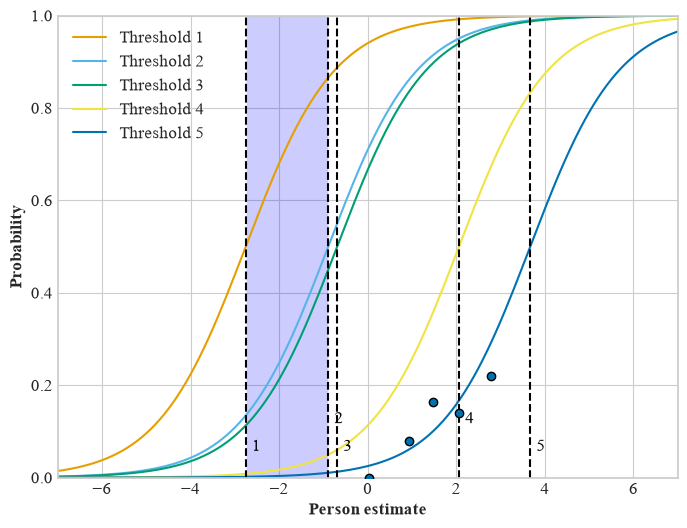

In [40]:
mfrm.threshold_ccs_bistretch('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bistretch_threshold_ccs')

Produce an item information function curve for Item 2

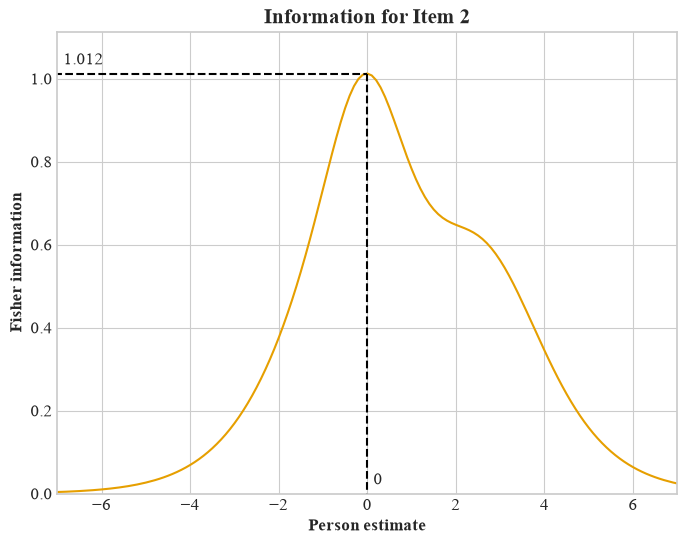

In [41]:
mfrm.iic_bistretch('Item_2', point_info_lines=[0], point_info_labels=True,
                   title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_bistretch_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

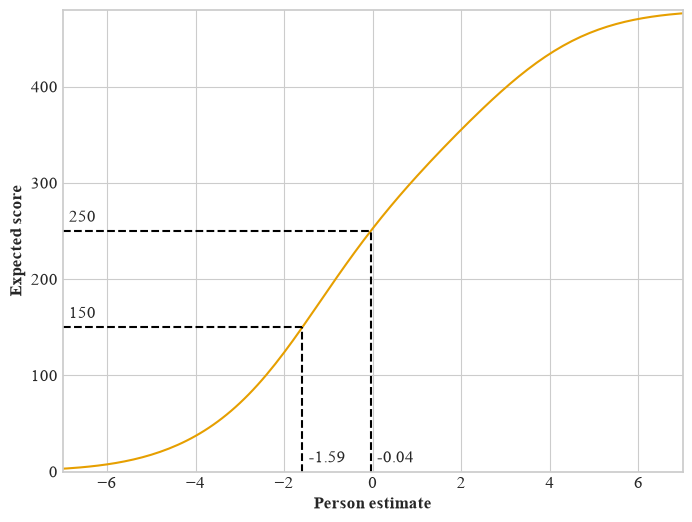

In [42]:
mfrm.tcc_bistretch(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bistretch_tcc')

Produce a test information curve

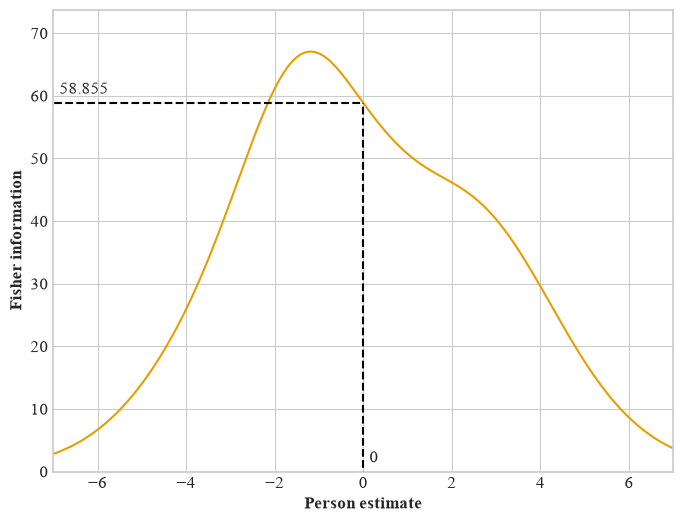

In [43]:
mfrm.test_info_bistretch(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bistretch_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

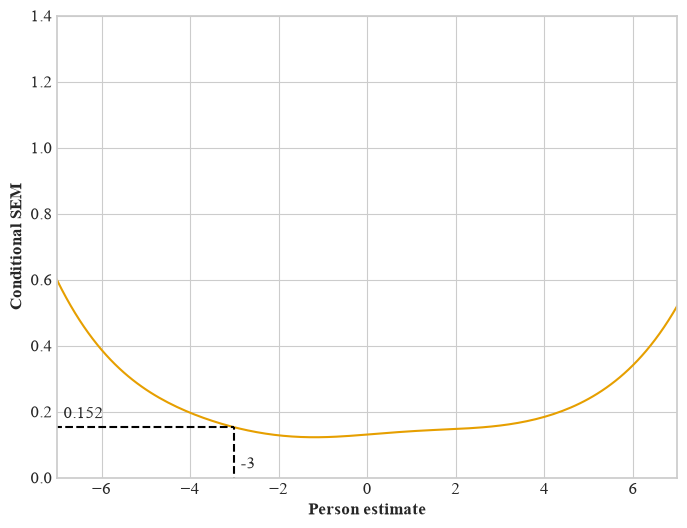

In [44]:
mfrm.test_csem_bistretch(point_csem_lines=[-3], point_csem_labels=True,
                         ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_bistretch_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

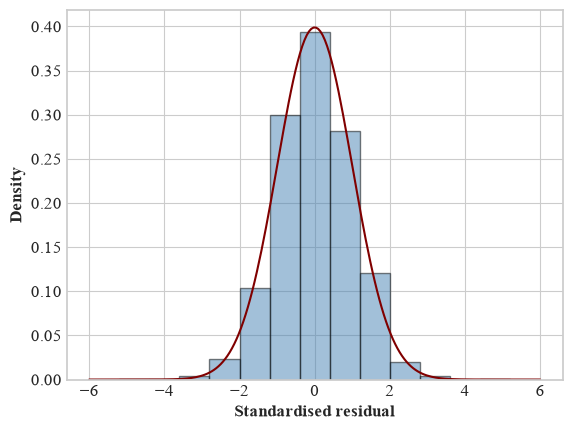

In [45]:
mfrm.std_residuals_plot_bistretch(bin_width=0.6, normal=True, filename='my_mfrm_bistretch_std_residuals_plot')

**Model selection.** Since `bistretch` is nested between `global` and `bivector` (and can also be compared directly against `centrality`/`pseudo_halo`), `model_selection()` can compare all eight MFRM rater representations directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including a direct three-way comparison of the stretch representations (`models=['centrality', 'pseudo_halo', 'bistretch']`).

Run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_bistretch_anchor(anchors)

CPU times: user 44.4 ms, sys: 577 μs, total: 45 ms
Wall time: 44.8 ms


Check the anchored item locations against the unanchored ones.

In [47]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_bistretch})
round(item_check, 3)

,Unanchored,Anchored
Item_1,1.025,1.000
Item_2,0.279,0.266
Item_3,-0.455,-0.554
Item_4,0.678,0.653
Item_5,0.888,1.020
Item_6,-0.187,-0.207
Item_7,-0.194,-0.275
Item_8,-1.034,-1.023
Item_9,-0.833,-0.836
Item_10,-0.166,-0.142


Check the anchored thresholds against the unanchored thresholds.

In [48]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_bistretch})
round(threshold_check, 3)

,Unanchored,Anchored
1,-3.034,-2.975
2,-1.171,-1.120
3,-0.969,-0.889
4,1.783,1.747
5,3.391,3.237


Check the anchored rater x item x threshold severities against the unanchored ones (two separate dataframes).

In [49]:
round(mfrm.raters_bistretch, 3)

1      2      3      4      5
rater   item                                      
Rater_1 Item_1   1.566  1.062  1.008  0.264 -0.170
        Item_2   1.362  0.858  0.804  0.060 -0.374
        Item_3   1.161  0.657  0.603 -0.141 -0.576
        Item_4   1.471  0.967  0.913  0.169 -0.265
        Item_5   1.528  1.025  0.970  0.227 -0.208
...                ...    ...    ...    ...    ...
Rater_8 Item_8   0.111  0.305  0.325  0.611  0.778
        Item_9   0.086  0.280  0.301  0.587  0.754
        Item_10  0.004  0.198  0.218  0.504  0.671
        Item_11  0.092  0.286  0.307  0.592  0.760
        Item_12 -0.125  0.068  0.089  0.375  0.542

[96 rows x 5 columns]

In [50]:
round(mfrm.anchor_raters_bistretch, 3)

1      2      3      4      5
rater   item                                      
Rater_1 Item_1   1.449  0.992  0.935  0.286 -0.081
        Item_2   1.226  0.769  0.712  0.063 -0.304
        Item_3   0.977  0.520  0.464 -0.185 -0.552
        Item_4   1.343  0.886  0.830  0.181 -0.186
        Item_5   1.455  0.998  0.941  0.292 -0.075
...                ...    ...    ...    ...    ...
Rater_8 Item_8  -0.083  0.173  0.205  0.568  0.774
        Item_9  -0.108  0.148  0.180  0.544  0.749
        Item_10 -0.200  0.057  0.088  0.452  0.658
        Item_11 -0.111  0.145  0.177  0.540  0.746
        Item_12 -0.338 -0.082 -0.050  0.313  0.519

[96 rows x 5 columns]

Produce a Wright map (unanchored), showing the person location distribution alongside an item strip and a rater panel (severity shift, lambda), plus two stacked stretch panels showing each rater's item-difficulty and threshold stretch multipliers (omega_items, omega_thresholds), with mean/±1SD/±2SD reference marks for persons

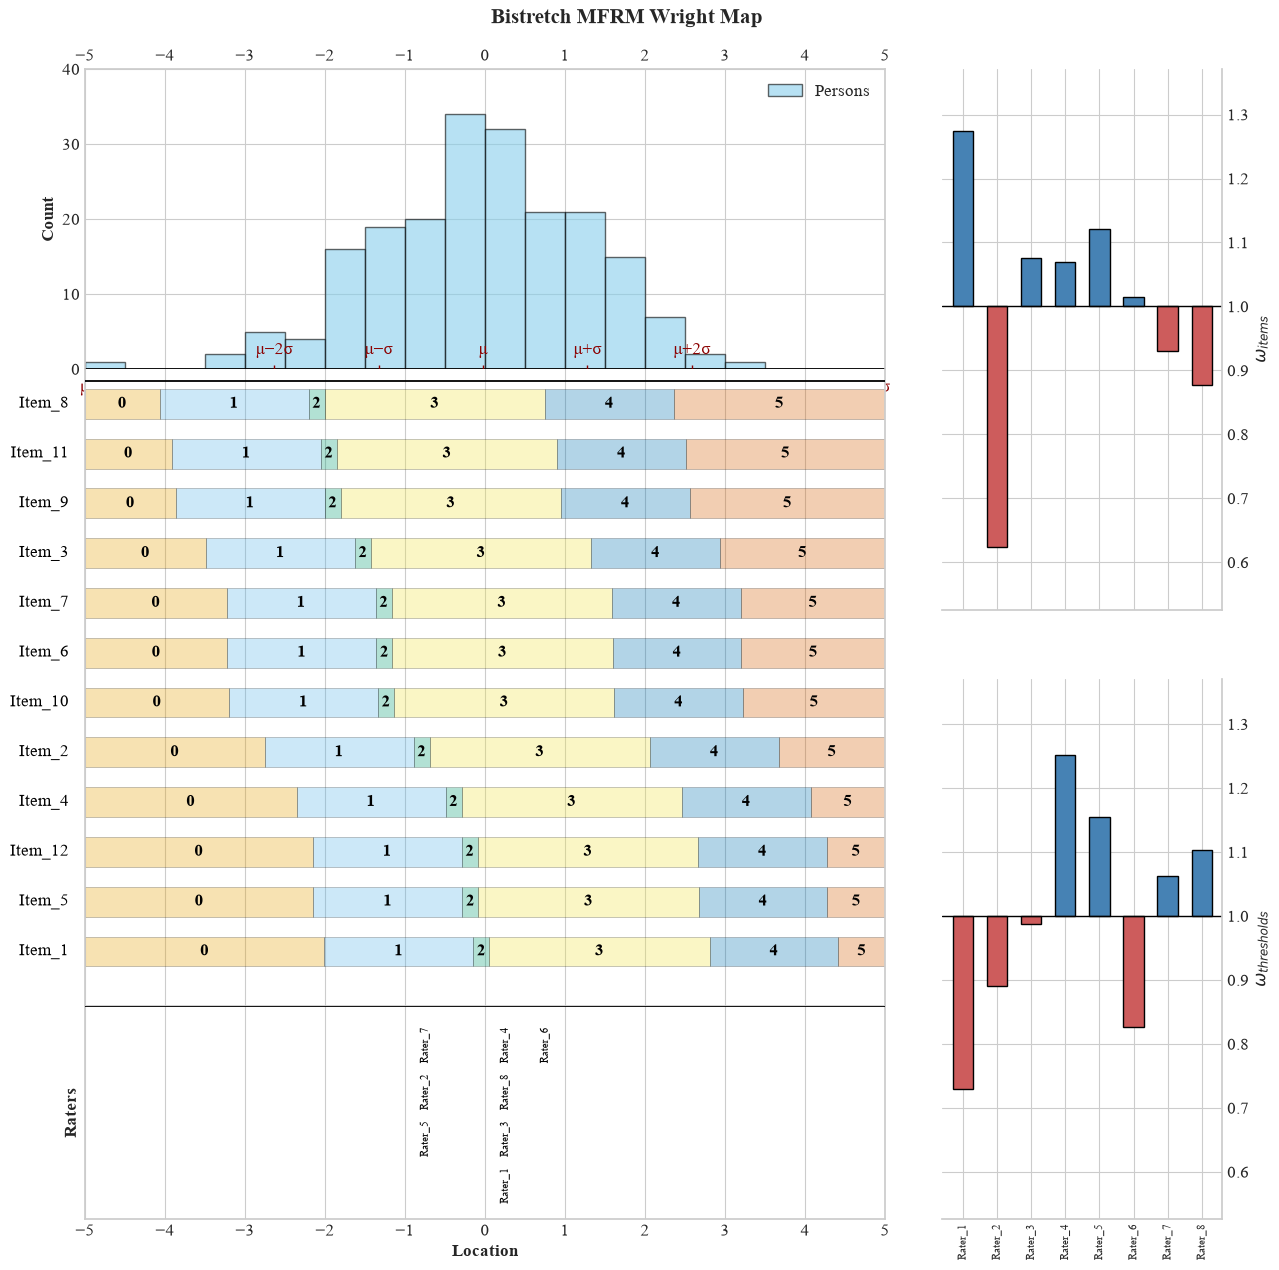

In [51]:
mfrm.wright_map_bistretch(item_strip=True, facet_labels=True, show_stretch=True, distribution_markers=True, title='Bistretch MFRM Wright Map', filename='my_mfrm_bistretch_wright_map')